# Notebook 01 - Exploration des données

## 1.0 - Setup

In [31]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration d'affichage
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')

# Chargement des données
df = pd.read_csv("../data/raw/application_train.csv")

print(f"Nombre de lignes    : {df.shape[0]:,}")
print(f"Nombre de colonnes  : {df.shape[1]}")

Nombre de lignes    : 307,511
Nombre de colonnes  : 122


## 1.1 - Structure du dataset

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [33]:
# Répartition des types de variables
print("Répartition des types de variables :")
print(df.dtypes.value_counts())

Répartition des types de variables :
float64    65
int64      41
str        16
Name: count, dtype: int64


In [34]:
# Liste des variables catégorielles
variables_categorielles = df.select_dtypes(include=['object']).columns.tolist()
print(f"Nombre de variables catégorielles : {len(variables_categorielles)}")
print("\nListe :")
for var in variables_categorielles:
    print(f"  - {var}")

Nombre de variables catégorielles : 16

Liste :
  - NAME_CONTRACT_TYPE
  - CODE_GENDER
  - FLAG_OWN_CAR
  - FLAG_OWN_REALTY
  - NAME_TYPE_SUITE
  - NAME_INCOME_TYPE
  - NAME_EDUCATION_TYPE
  - NAME_FAMILY_STATUS
  - NAME_HOUSING_TYPE
  - OCCUPATION_TYPE
  - WEEKDAY_APPR_PROCESS_START
  - ORGANIZATION_TYPE
  - FONDKAPREMONT_MODE
  - HOUSETYPE_MODE
  - WALLSMATERIAL_MODE
  - EMERGENCYSTATE_MODE


C:\Users\bouas\AppData\Local\Temp\ipykernel_19948\3243345321.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categorielles = df.select_dtypes(include=['object']).columns.tolist()


In [35]:
# Nombre de modalités par variable catégorielle
print("Nombre de modalités par variable catégorielle :\n")
for var in variables_categorielles:
    n_modalites = df[var].nunique()
    print(f"  {var:35s} → {n_modalites:3d} modalités")

Nombre de modalités par variable catégorielle :

  NAME_CONTRACT_TYPE                  →   2 modalités
  CODE_GENDER                         →   3 modalités
  FLAG_OWN_CAR                        →   2 modalités
  FLAG_OWN_REALTY                     →   2 modalités
  NAME_TYPE_SUITE                     →   7 modalités
  NAME_INCOME_TYPE                    →   8 modalités
  NAME_EDUCATION_TYPE                 →   5 modalités
  NAME_FAMILY_STATUS                  →   6 modalités
  NAME_HOUSING_TYPE                   →   6 modalités
  OCCUPATION_TYPE                     →  18 modalités
  WEEKDAY_APPR_PROCESS_START          →   7 modalités
  ORGANIZATION_TYPE                   →  58 modalités
  FONDKAPREMONT_MODE                  →   4 modalités
  HOUSETYPE_MODE                      →   3 modalités
  WALLSMATERIAL_MODE                  →   7 modalités
  EMERGENCYSTATE_MODE                 →   2 modalités


### Observations 

Le dataset application_train.csv du dataset Home Credit Default Risk 
contient les caractéristiques suivantes :

- **307 511 demandes de crédit** (lignes)
- **122 variables** (colonnes)
- **Variable cible** : TARGET (int64), 0 = remboursé, 1 = défaut
- **106 variables numériques** (65 float64 + 41 int64)
- **16 variables catégorielles** (object)

Les variables catégorielles présentent des cardinalités variables 
(de 2 modalités pour NAME_CONTRACT_TYPE à ~58 pour ORGANIZATION_TYPE)

## 1.2 - Variable cible

In [36]:
# Variable cible
print(f"Type de TARGET : {df['TARGET'].dtype}")
print(f"Valeurs uniques : {df['TARGET'].unique()}")

Type de TARGET : int64
Valeurs uniques : [1 0]


In [37]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Taux de défaut : 8.07%


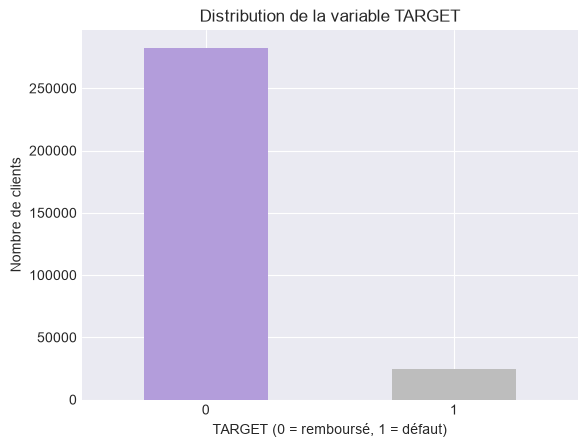

In [38]:
# Taux de défaut
taux_defaut = df["TARGET"].mean()
print(f"Taux de défaut : {taux_defaut:.2%}")

# Visualisation
df["TARGET"].value_counts().plot(
    kind="bar", 
    color=['#B39DDB', '#BDBDBD']
)
plt.title("Distribution de la variable TARGET")
plt.xlabel("TARGET (0 = remboursé, 1 = défaut)")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.savefig("../outputs/figures/01_distribution_target.png", dpi=150, bbox_inches='tight')
plt.show()


## 1.3 - Valeurs manquantes

In [39]:
n_avec_manquants = (df.isnull().sum() > 0).sum()
n_colonnes_pleines = df.shape[1] - n_avec_manquants

print(f"Colonnes avec des valeurs manquantes : {n_avec_manquants} / {df.shape[1]}")
print(f"Colonnes complètes                   : {n_colonnes_pleines} / {df.shape[1]}")

Colonnes avec des valeurs manquantes : 67 / 122
Colonnes complètes                   : 55 / 122


In [40]:
# Valeurs manquantes
manquants = df.isnull().mean().sort_values(ascending=False) * 100
print("Top 20 des colonnes avec le plus de valeurs manquantes :")
print(manquants.head(20).round(1))

Top 20 des colonnes avec le plus de valeurs manquantes :
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
COMMONAREA_MEDI             69.9
NONLIVINGAPARTMENTS_MEDI    69.4
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
LIVINGAPARTMENTS_MODE       68.4
FLOORSMIN_MODE              67.8
FLOORSMIN_AVG               67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_AVG             66.5
YEARS_BUILD_MODE            66.5
YEARS_BUILD_MEDI            66.5
OWN_CAR_AGE                 66.0
LANDAREA_MEDI               59.4
LANDAREA_AVG                59.4
LANDAREA_MODE               59.4
dtype: float64


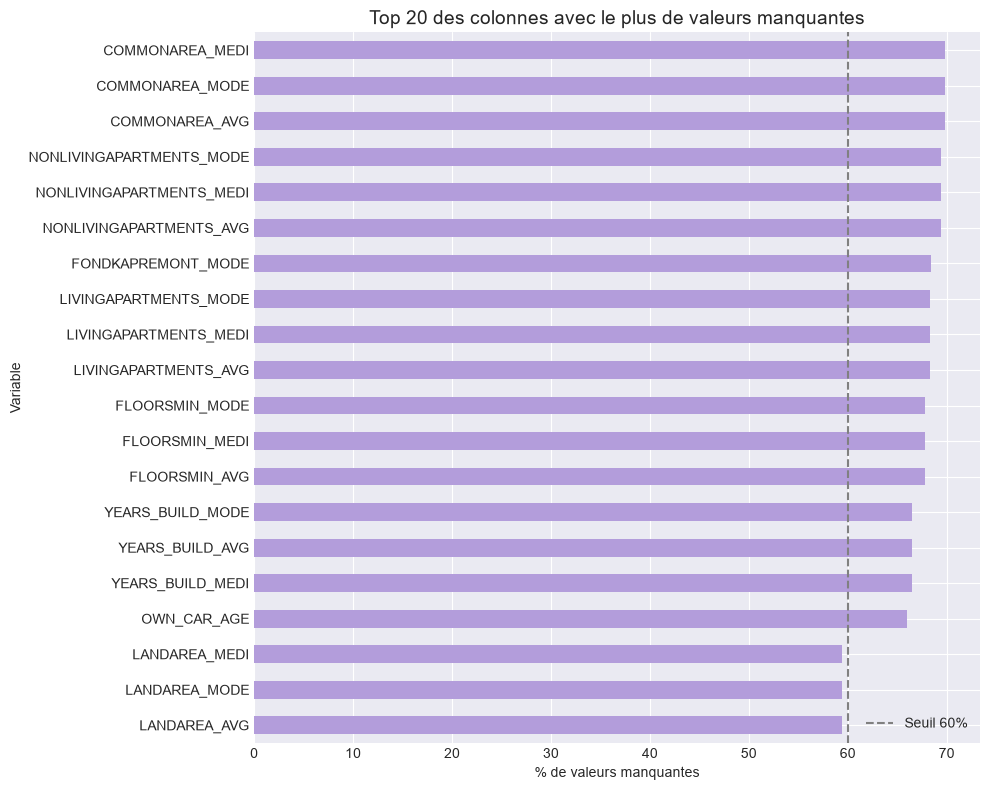

In [41]:
top_20 = manquants.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_20.sort_values().plot(kind='barh', color= '#B39DDB', ax=ax)
ax.set_title("Top 20 des colonnes avec le plus de valeurs manquantes", fontsize=14)
ax.set_xlabel("% de valeurs manquantes")
ax.set_ylabel("Variable")
ax.axvline(x=60, color='gray', linestyle='--', label='Seuil 60%')
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/02_valeurs_manquantes_top20.png", dpi=150, bbox_inches='tight')
plt.show()

In [42]:
seuils = [10, 25, 50, 60, 75, 90]
print("Nombre de colonnes selon le taux de valeurs manquantes :\n")
for seuil in seuils:
    n = (manquants > seuil).sum()
    print(f"  Plus de {seuil}% manquants : {n} colonnes")

Nombre de colonnes selon le taux de valeurs manquantes :

  Plus de 10% manquants : 57 colonnes
  Plus de 25% manquants : 50 colonnes
  Plus de 50% manquants : 41 colonnes
  Plus de 60% manquants : 17 colonnes
  Plus de 75% manquants : 0 colonnes
  Plus de 90% manquants : 0 colonnes


### Observations Valeurs manquantes

- **67 colonnes sur 122** présentent des valeurs manquantes
- **17 colonnes ont plus de 60 % de manquants** Elles sont toutes liées aux 
  caractéristiques du logement/immeuble (COMMONAREA, NONLIVINGAPARTMENTS, 
  FLOORSMIN, YEARS_BUILD, etc.), déclinées en 3 variantes (_AVG, _MODE, _MEDI)
- OWN_CAR_AGE (66 % manquants) est un cas particulier : la valeur est 
  non-applicable pour les clients sans voiture, pas réellement "manquante"
- Les variables LANDAREA_* sont à 59,4 %, juste sous le seuil de 60 %

**Stratégie envisagée** :
- Suppression des colonnes avec >60 % de manquants
- Imputation par la médiane pour les numériques restantes
- Imputation par le mode pour les catégorielles restantes
- Traitement spécifique de OWN_CAR_AGE : création d'une variable 
  binaire "possède une voiture" plutôt que suppression

## 1.4 - Détection des valeurs aberrantes

In [43]:
print("Statistiques descriptives de DAYS_EMPLOYED :")
print(df["DAYS_EMPLOYED"].describe().round(2))

print(f"\nValeurs les plus fréquentes :")
print(df["DAYS_EMPLOYED"].value_counts().head(5))

Statistiques descriptives de DAYS_EMPLOYED :
count    307511.00
mean      63815.05
std      141275.77
min      -17912.00
25%       -2760.00
50%       -1213.00
75%        -289.00
max      365243.00
Name: DAYS_EMPLOYED, dtype: float64

Valeurs les plus fréquentes :
DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64


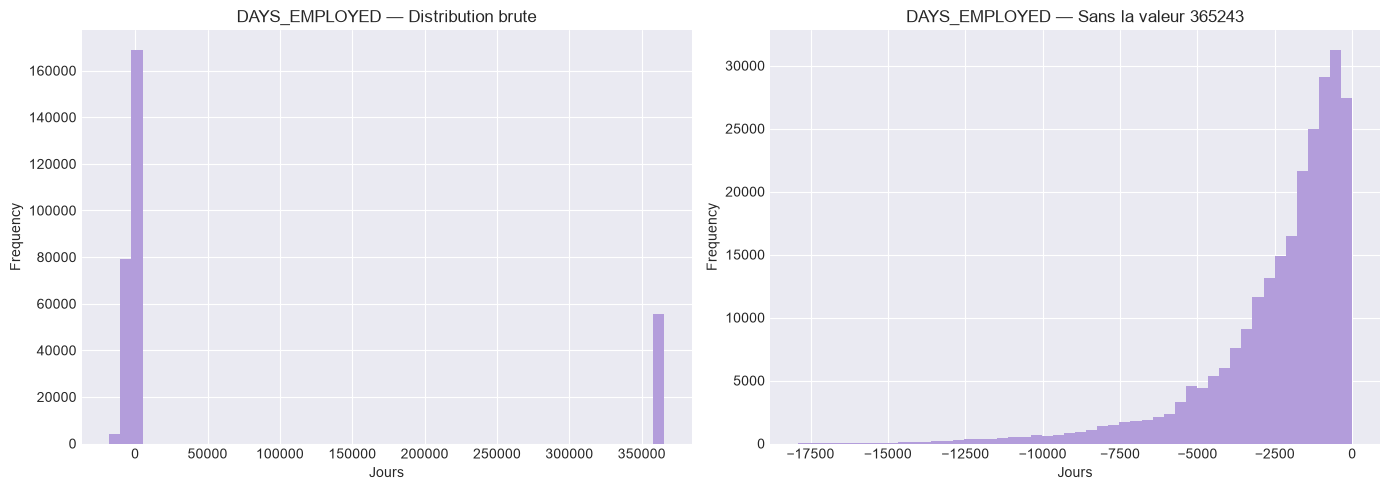

Occurrences de 365243 : 55,374 (18.0% du dataset)


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant nettoyage
df["DAYS_EMPLOYED"].plot(kind='hist', bins=50, color='#B39DDB', ax=axes[0])
axes[0].set_title("DAYS_EMPLOYED — Distribution brute")
axes[0].set_xlabel("Jours")

# Après exclusion de la valeur suspecte
df_filtre = df[df["DAYS_EMPLOYED"] != 365243]
df_filtre["DAYS_EMPLOYED"].plot(kind='hist', bins=50, color='#B39DDB', ax=axes[1])
axes[1].set_title("DAYS_EMPLOYED — Sans la valeur 365243")
axes[1].set_xlabel("Jours")

plt.tight_layout()
plt.savefig("../outputs/figures/03_days_employed_aberrant.png", dpi=150, bbox_inches='tight')
plt.show()

n_aberrants = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"Occurrences de 365243 : {n_aberrants:,} ({n_aberrants / len(df):.1%} du dataset)")

In [45]:
print("Distribution de CODE_GENDER :")
print(df["CODE_GENDER"].value_counts())

Distribution de CODE_GENDER :
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


### Observations des valeurs aberrantes

**DAYS_EMPLOYED** :
- La valeur `365243` (~1000 ans) apparaît **55 374 fois** (18 % du dataset)
- C'est un code caché pour "sans emploi" ou "non-applicable"
- Toutes les valeurs normales sont négatives (convention Home Credit)
- À traiter au Bloc 2 : remplacer 365243 par NaN puis imputer, 
  ou créer une variable binaire "sans emploi"

**CODE_GENDER** :
- 4 occurrences de la modalité `XNA` (probable code pour "inconnu")
- À traiter au Bloc 2 : supprimer ces 4 lignes ou imputer par le mode ("F")
- Impact négligeable (4 lignes sur 307 511)

## 5. Statistiques descriptives des variables numériques clés

In [46]:
variables_cles = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

df[variables_cles].describe().round(2)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS
count,3.075110e+05,307511.00,307499.00,307233.00,307511.00,307511.00,307509.00
mean,1.687979e+05,599026.00,27108.57,538396.21,-16037.00,0.42,2.15
std,2.371231e+05,402490.78,14493.74,369446.46,4363.99,0.72,0.91
min,2.565000e+04,45000.00,1615.50,40500.00,-25229.00,0.00,1.00
25%,1.125000e+05,270000.00,16524.00,238500.00,-19682.00,0.00,2.00
50%,1.471500e+05,513531.00,24903.00,450000.00,-15750.00,0.00,2.00
75%,2.025000e+05,808650.00,34596.00,679500.00,-12413.00,1.00,3.00
max,1.170000e+08,4050000.00,258025.50,4050000.00,-7489.00,19.00,20.00


In [47]:
# Conversion de l'âge
df_viz = df.copy()
df_viz['AGE'] = -df_viz['DAYS_BIRTH'] / 365

print("Distribution de l'âge des clients :")
print(df_viz['AGE'].describe().round(1))

Distribution de l'âge des clients :
count    307511.0
mean         43.9
std          12.0
min          20.5
25%          34.0
50%          43.2
75%          53.9
max          69.1
Name: AGE, dtype: float64


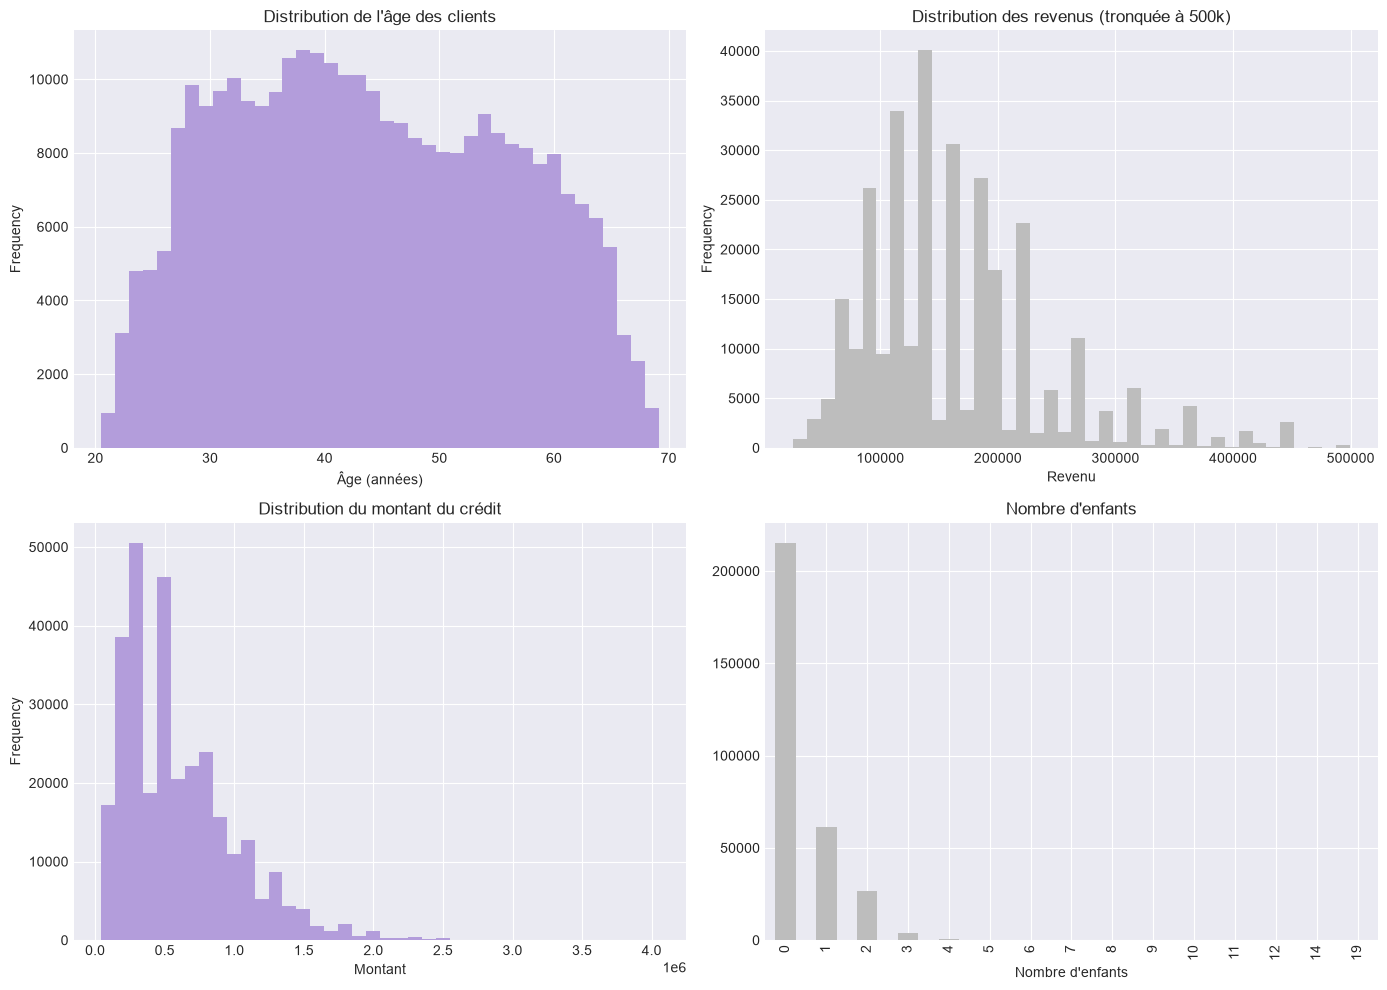

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Âge
df_viz['AGE'].plot(kind='hist', bins=40, color='#B39DDB', ax=axes[0, 0])
axes[0, 0].set_title("Distribution de l'âge des clients")
axes[0, 0].set_xlabel("Âge (années)")

# Revenu (tronqué à 500k pour lisibilité)
df_viz[df_viz['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL'].plot(
    kind='hist', bins=40, color='#BDBDBD', ax=axes[0, 1]
)
axes[0, 1].set_title("Distribution des revenus (tronquée à 500k)")
axes[0, 1].set_xlabel("Revenu")

# Montant du crédit
df_viz['AMT_CREDIT'].plot(kind='hist', bins=40, color='#B39DDB', ax=axes[1, 0])
axes[1, 0].set_title("Distribution du montant du crédit")
axes[1, 0].set_xlabel("Montant")

# Nombre d'enfants
df_viz['CNT_CHILDREN'].value_counts().sort_index().plot(
    kind='bar', color='#BDBDBD', ax=axes[1, 1]
)
axes[1, 1].set_title("Nombre d'enfants")
axes[1, 1].set_xlabel("Nombre d'enfants")

plt.tight_layout()
plt.savefig("../outputs/figures/04_distributions_variables_cles.png", dpi=150, bbox_inches='tight')
plt.show()

### Observations des variables numériques clés

- **Âge** : entre 20,5 et 69 ans, médiane à 43 ans, la distribution cohérente
- **Revenus** : médiane à ~147 000, mais présence d'outliers extrêmes 
  (max à 117 millions, soit 800× la médiane). À traiter
  par winsorization ou transformation logarithmique.
- **Montant du crédit** : médiane à ~514 000, max à 4 050 000. 
  Distribution étalée mais cohérente avec la diversité de produits.
- **Nombre d'enfants** : majoritairement 0 (médiane), 75 % des clients 
  ont 0 ou 1 enfant. Max à 19, cas rare mais pas aberrant.
- **DAYS_BIRTH** est en jours négatifs, la conversion en années 
  (AGE = -DAYS_BIRTH / 365) sera faite au Bloc 2.

## 6. Corrélations avec la variable cible

In [49]:
correlations = df.corr(numeric_only=True)['TARGET'].sort_values()

print("Top 15 corrélations NÉGATIVES (protègent du défaut) :\n")
print(correlations.head(15).round(4))

print("\n\nTop 15 corrélations POSITIVES (augmentent le risque) :\n")
print(correlations.tail(16).round(4))

Top 15 corrélations NÉGATIVES (protègent du défaut) :

EXT_SOURCE_3                 -0.1789
EXT_SOURCE_2                 -0.1605
EXT_SOURCE_1                 -0.1553
DAYS_EMPLOYED                -0.0449
FLOORSMAX_AVG                -0.0440
FLOORSMAX_MEDI               -0.0438
FLOORSMAX_MODE               -0.0432
AMT_GOODS_PRICE              -0.0396
REGION_POPULATION_RELATIVE   -0.0372
ELEVATORS_AVG                -0.0342
ELEVATORS_MEDI               -0.0339
FLOORSMIN_AVG                -0.0336
FLOORSMIN_MEDI               -0.0334
LIVINGAREA_AVG               -0.0330
LIVINGAREA_MEDI              -0.0327
Name: TARGET, dtype: float64


Top 15 corrélations POSITIVES (augmentent le risque) :

FLAG_WORK_PHONE                0.0285
DEF_60_CNT_SOCIAL_CIRCLE       0.0313
DEF_30_CNT_SOCIAL_CIRCLE       0.0322
LIVE_CITY_NOT_WORK_CITY        0.0325
OWN_CAR_AGE                    0.0376
DAYS_REGISTRATION              0.0420
FLAG_DOCUMENT_3                0.0443
REG_CITY_NOT_LIVE_CITY         0.0444

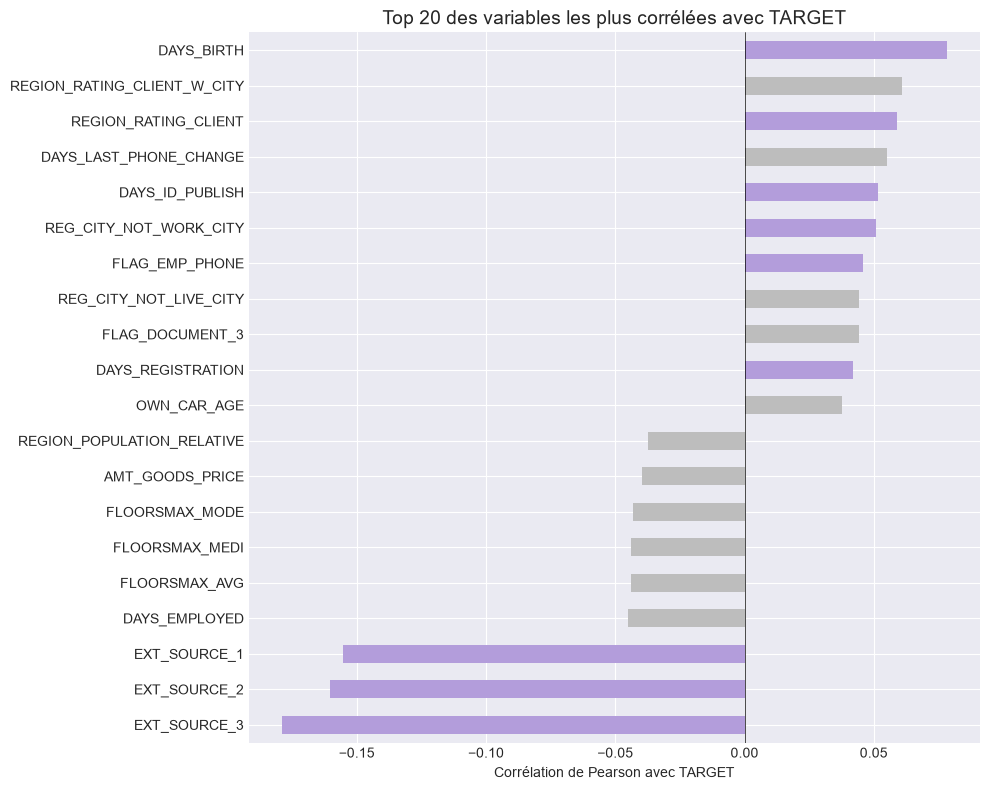

In [50]:
top_corr = correlations.drop('TARGET').abs().sort_values(ascending=False).head(20)
top_corr_signed = correlations.loc[top_corr.index]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#B39DDB' if x < 0 else '#BDBDBD' for x in top_corr_signed]
top_corr_signed.sort_values().plot(kind='barh', color=colors, ax=ax)
ax.set_title("Top 20 des variables les plus corrélées avec TARGET", fontsize=14)
ax.set_xlabel("Corrélation de Pearson avec TARGET")
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/05_top_correlations_target.png", dpi=150, bbox_inches='tight')
plt.show()

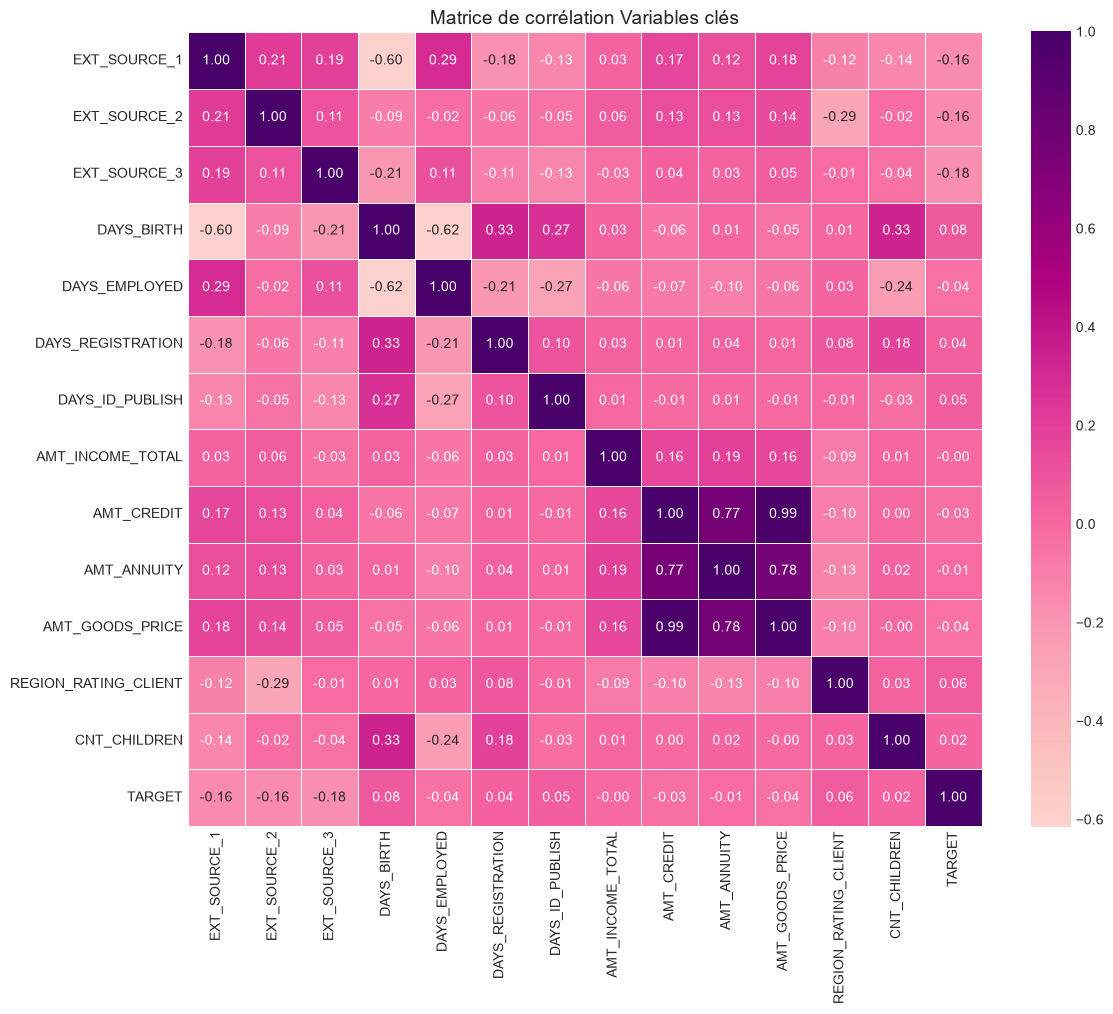

In [51]:
# Matrice de corrélations
variables_matrice = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'REGION_RATING_CLIENT', 'CNT_CHILDREN',
    'TARGET'
]

matrice_corr = df[variables_matrice].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matrice_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='RdPu',
    center=0, 
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matrice de corrélation Variables clés", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/figures/05b_matrice_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

### Observations corrélations avec TARGET

Les corrélations individuelles restent **faibles** (max ~0,18 en valeur absolue),
c'est typique du scoring de crédit, où le risque résulte d'une combinaison 
de facteurs plutôt que d'un facteur isolé. C'est ce qui justifie l'usage 
de modèles multivariés.

**Variables les plus prédictives** :
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` : scores externes anonymisés, 
  de loin les plus corrélés avec TARGET (-0,15 à -0,18). Leur nature exacte 
  n'est pas documentée, c'est une limite du dataset à mentionner.
- `DAYS_BIRTH` (+0,078) : les clients plus jeunes présentent un risque 
  de défaut plus élevé. Observation classique en scoring.
- `DAYS_EMPLOYED` (-0,045) : l'ancienneté professionnelle a un effet protecteur.
- `REGION_RATING_CLIENT` (+0,061) : la notation de la région d'habitation 
  est faiblement associée au risque.

**Implication pour la modélisation** : aucune variable seule ne suffit à prédire 
le défaut. La valeur ajoutée des modèles ML (Random Forest, XGBoost) réside 
justement dans leur capacité à capturer les interactions entre ces variables faiblement prédictives.

## 7. Analyse des variables catégorielles

In [52]:
# taux de défaut par modalité pour les 5 variables catégorielles les plus intéressantes
variables_cat_cles = [
    'CODE_GENDER',
    'NAME_CONTRACT_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE'
]

for var in variables_cat_cles:
    print(f"\n=== {var} ===")
    tab = df.groupby(var, observed=False)['TARGET'].agg(['mean', 'count'])
    tab.columns = ['Taux de défaut', 'Effectif']
    tab['Taux de défaut'] = (tab['Taux de défaut'] * 100).round(2)
    tab = tab.sort_values('Taux de défaut', ascending=False)
    print(tab)


=== CODE_GENDER ===
             Taux de défaut  Effectif
CODE_GENDER                          
M                     10.14    105059
F                      7.00    202448
XNA                    0.00         4

=== NAME_CONTRACT_TYPE ===
                    Taux de défaut  Effectif
NAME_CONTRACT_TYPE                          
Cash loans                    8.35    278232
Revolving loans               5.48     29279

=== NAME_EDUCATION_TYPE ===
                               Taux de défaut  Effectif
NAME_EDUCATION_TYPE                                    
Lower secondary                         10.93      3816
Secondary / secondary special            8.94    218391
Incomplete higher                        8.48     10277
Higher education                         5.36     74863
Academic degree                          1.83       164

=== NAME_FAMILY_STATUS ===
                      Taux de défaut  Effectif
NAME_FAMILY_STATUS                            
Civil marriage                  9.94  

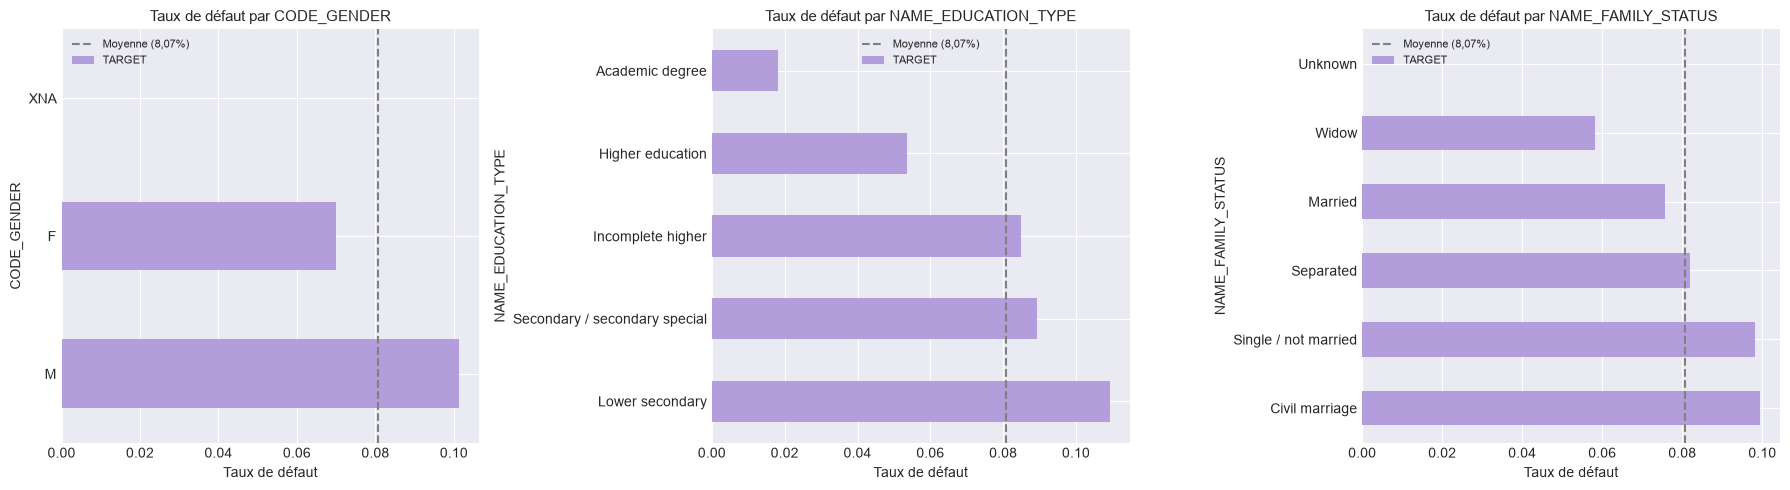

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables_a_tracer = ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

for i, var in enumerate(variables_a_tracer):
    tab = df.groupby(var, observed=False)['TARGET'].mean().sort_values(ascending=False)
    tab.plot(kind='barh', color='#B39DDB', ax=axes[i])
    axes[i].set_title(f"Taux de défaut par {var}", fontsize=11)
    axes[i].set_xlabel("Taux de défaut")
    axes[i].axvline(x=0.0807, color='gray', linestyle='--', label='Moyenne (8,07%)')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/06_taux_defaut_categoriel.png", dpi=150, bbox_inches='tight')
plt.show()

### Observations variables catégorielles

- **CODE_GENDER** : les hommes présentent un taux de défaut supérieur 
  aux femmes (10,14 % vs 7,00 %).
- **NAME_EDUCATION_TYPE** : relation quasi-monotone entre niveau 
  d'éducation et risque de défaut — de 10,93 % (secondaire inférieur) 
  à 1,83 % (diplôme académique).
- **NAME_FAMILY_STATUS** : les couples en union civile et les célibataires 
  présentent un risque supérieur (~10 %) aux mariés (7,56 %) et aux veufs (5,82 %).
- **NAME_INCOME_TYPE** : "Maternity leave" (40 %) et "Unemployed" (36 %) 
  affichent des taux très élevés, mais sur des effectifs minuscules 
  (5 et 22 clients).

**Implication méthodologique** : les variables catégorielles portent 
de l'information prédictive réelle. Leur encodage et le traitement 
des modalités rares seront des enjeux importants du prétraitement.

## 8. Synthèse générale

### Chiffres clés du dataset

| Élément | Valeur |
|---|---|
| Nombre d'observations | 307 511 |
| Nombre de variables | 122 |
| Variables numériques | 106 (65 float64, 41 int64) |
| Variables catégorielles | 16 |
| Taux de défaut | 8,07 % |
| Colonnes avec valeurs manquantes | 67 / 122 |
| Colonnes avec >60 % de manquants | 17 |
| Valeur aberrante DAYS_EMPLOYED = 365243 | 55 374 clients (18 %) |

### Variables les plus prédictives identifiées

| Variable | Corrélation avec TARGET | Type |
|---|---|---|
| EXT_SOURCE_3 | -0,179 | Score externe anonymisé |
| EXT_SOURCE_2 | -0,161 | Score externe anonymisé |
| EXT_SOURCE_1 | -0,155 | Score externe anonymisé |
| DAYS_BIRTH | +0,078 | Âge du client |
| REGION_RATING_CLIENT_W_CITY | +0,061 | Notation de la région |
| DAYS_EMPLOYED | -0,045 | Ancienneté professionnelle |

### Enjeux méthodologiques identifiés

1. **Déséquilibre des classes (92/8)** → découpage stratifié, class_weight, métriques adaptées
2. **17 colonnes avec >60 % de manquants** → suppression (caractéristiques immobilières secondaires)
3. **Valeurs aberrantes** → DAYS_EMPLOYED = 365243 à remplacer par NaN, CODE_GENDER XNA à traiter
4. **Modalités catégorielles rares** → regrouper les modalités à très faible effectif (Maternity leave, Unemployed, etc.)
5. **Outliers extrêmes sur les revenus** → winsorization ou transformation logarithmique
6. **Cardinalité élevée** → ORGANIZATION_TYPE (~58 modalités) nécessitera un encodage adapté
7. **Variables sensibles** → genre et âge sont prédictifs, à discuter sur le plan éthique